In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Data Cleaning

## Load Dataset

The first step is to load the raw customer churn dataset into a pandas DataFrame. This dataset will undergo a series of data quality checks and cleaning operations before it is used for exploratory data analysis and machine learning.

In [2]:
from pathlib import Path
import pandas as pd


def load_data(filepath):
    """
    Load a CSV dataset.

    Parameters
    ----------
    filepath : str or Path
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        Loaded dataset.
    """
    filepath = Path(filepath)

    if not filepath.exists():
        raise FileNotFoundError(f"Dataset not found: {filepath}")

    return pd.read_csv(filepath)

In [3]:
# load dataset
# Since your notebook is inside the notebooks folder and the dataset is inside data/raw, use:

from src.data_utils import load_data

telco_df = load_data(
    "../data/raw/Telco_Customer_Churn.csv"
)

# Preview the first five rows
telco_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df= telco_df.copy()   

## Initial Data Inspection

Before cleaning the dataset, it is important to understand its overall structure. This includes checking the number of observations, feature names, data types, and obtaining summary statistics. This step helps identify potential data quality issues such as incorrect data types, missing values, and unexpected column formats.

In [5]:
def inspect_dataframe(df):
    """
    Display basic information about a DataFrame.
    """
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

    print("\nData Types")
    display(df.dtypes)

    print("\nNumerical Summary")
    display(df.describe())

    print("\nComplete Summary")
    display(df.describe(include="all"))

In [6]:
inspect_dataframe(df)

Rows: 7043
Columns: 21

Data Types


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Numerical Summary


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Complete Summary


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Summary Statistics:

**df.describe(include="all")** is used to obtain descriptive statistics for both numerical and categorical variables. This provides an overview of the dataset, including central tendency, spread, unique category counts, and the most frequent values, helping identify potential data quality issues before further analysis.

## Data Type Validation

Machine learning models require variables to have appropriate data types. During this step, each feature is inspected to ensure it has the correct format. The `TotalCharges` column is commonly stored as text because of blank values and must be converted to a numeric data type.

In [8]:
# Check data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
# Looking at your dataset, there is one column with an incorrect datatype: "TotalCharges" column

# Check the values causing the problem
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [10]:
def convert_to_numeric(df, column, errors="coerce"):
    """
    Convert a DataFrame column to numeric values.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    column : str
        Column to convert.
    errors : str, default="coerce"
        How invalid parsing should be handled.

    Returns
    -------
    pd.DataFrame
        DataFrame with converted column.
    """
    df = df.copy()

    df[column] = pd.to_numeric(
        df[column].replace(r"^\s*$", pd.NA, regex=True),
        errors=errors
    )

    return df

df = convert_to_numeric(df, "TotalCharges")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [11]:
# Verify the updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Missing Value Analysis

Missing values can reduce the quality of analysis and negatively affect model performance. This section identifies missing values, investigates their source, and applies an appropriate cleaning strategy.

In [12]:
# Calculate percentage of missing values

def missing_value_report(df):
    """
    Return missing-value counts and percentages.
    """
    report = pd.DataFrame({
        "Missing Values": df.isna().sum(),
        "Percentage": (df.isna().mean() * 100).round(2)
    })

    return report[report["Missing Values"] > 0].sort_values(
        "Missing Values",
        ascending=False
    )

In [13]:
missing_value_report(df)

,Missing Values,Percentage
TotalCharges,11,0.16


In [14]:
# Display rows with missing values
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


# Create a business-rule function

This function is specific to this project and it is worthwhile because it's an important business rule.

Missing TotalCharges values were investigated and found to occur only among customers with zero tenure. Since these customers have no accumulated billing history, assigning zero is more consistent with the business meaning of the variable than statistical imputation.

In [15]:
def fix_zero_tenure_total_charges(df):
    """
    Set TotalCharges to zero for customers with zero tenure.

    This reflects the business assumption that customers
    with no tenure have no accumulated billing history.
    """
    df = df.copy()

    mask = (
        df["tenure"].eq(0)
        & df["TotalCharges"].isna()
    )

    df.loc[mask, "TotalCharges"] = 0

    return df

In [16]:
df = fix_zero_tenure_total_charges(df)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# check the distribution of customers across tenure values

df["tenure"].value_counts().sort_index() # or df.groupby("tenure").size()

tenure
0      11
1     613
2     238
3     200
4     176
     ... 
68    100
69     95
70    119
71    170
72    362
Name: count, Length: 73, dtype: int64

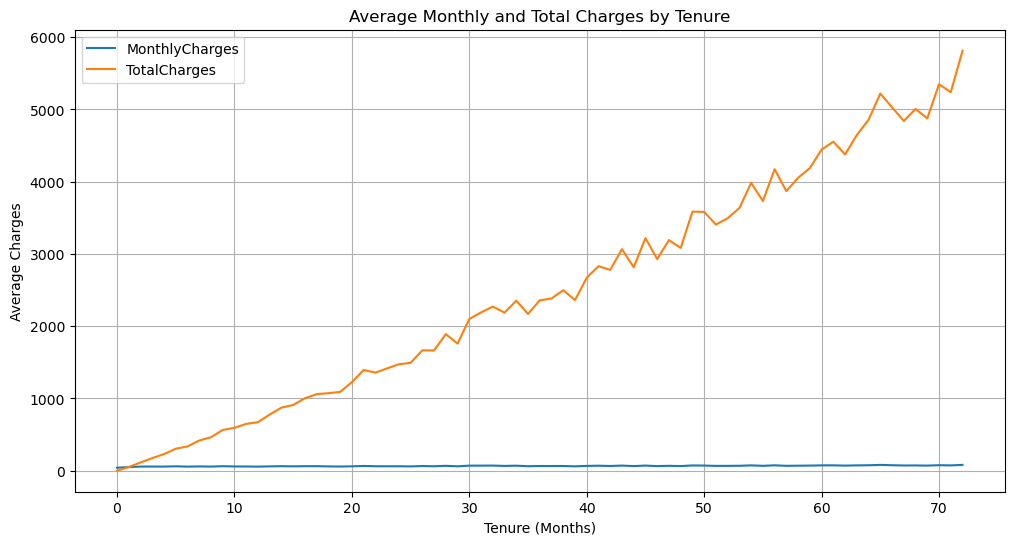

In [18]:
# Average charges by tenure

charges_by_tenure = df.groupby("tenure")[["MonthlyCharges", "TotalCharges"]].mean()

charges_by_tenure.head()

# visualize it:

charges_by_tenure.plot(figsize=(12, 6))
plt.title("Average Monthly and Total Charges by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Average Charges")
plt.grid(True)
plt.show()

## Duplicate Analysis

Duplicate records may introduce bias during analysis and model training. This section checks for duplicated observations and verifies that each customer has a unique identifier.

In [19]:
def duplicate_report(df, id_column=None):
    """
    Report duplicate rows and optionally duplicate IDs.
    """
    report = {
        "duplicate_rows": df.duplicated().sum()
    }

    if id_column is not None:
        report["duplicate_ids"] = df[id_column].duplicated().sum()

    return report

In [20]:
duplicate_report(df, id_column="customerID")

{'duplicate_rows': np.int64(0), 'duplicate_ids': np.int64(0)}

In [21]:
def remove_duplicates(df):
    """
    Remove duplicate rows and reset the index.
    """
    return df.drop_duplicates().reset_index(drop=True)

df = remove_duplicates(df)

In [22]:
# check for class imbalance

def class_distribution(df, target):
    """
    Return class counts and percentages.
    """
    counts = df[target].value_counts(dropna=False)

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": (counts / len(df) * 100).round(2)
    })

    return distribution

class_distribution(df, "Churn")

,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


In [23]:
def plot_class_distribution(
    df,
    column,
    title=None,
    figsize=(6, 4)
):
    """
    Plot class distribution with percentage annotations.
    """
    plt.figure(figsize=figsize)

    ax = sns.countplot(data=df, x=column)

    total = len(df)

    for patch in ax.patches:
        percentage = 100 * patch.get_height() / total

        ax.annotate(
            f"{percentage:.1f}%",
            (
                patch.get_x() + patch.get_width() / 2,
                patch.get_height()
            ),
            ha="center",
            va="bottom"
        )

    ax.set_title(title or f"{column} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

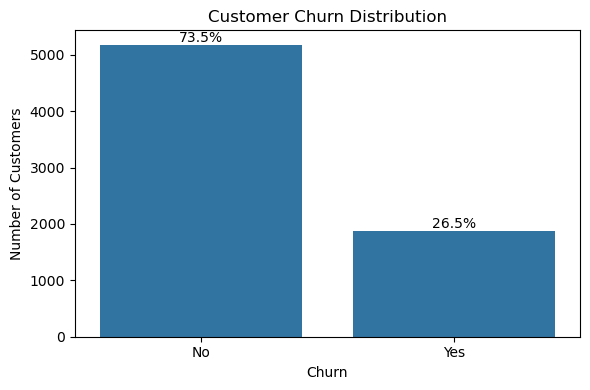

In [24]:
plot_class_distribution(
    df,
    "Churn",
    title="Customer Churn Distribution"
)

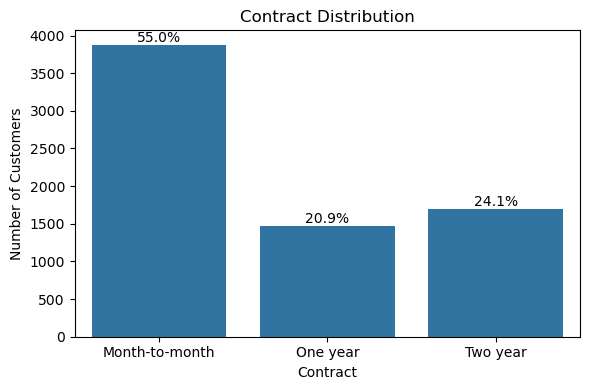

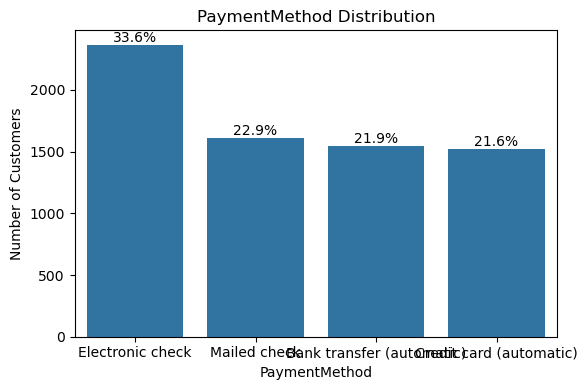

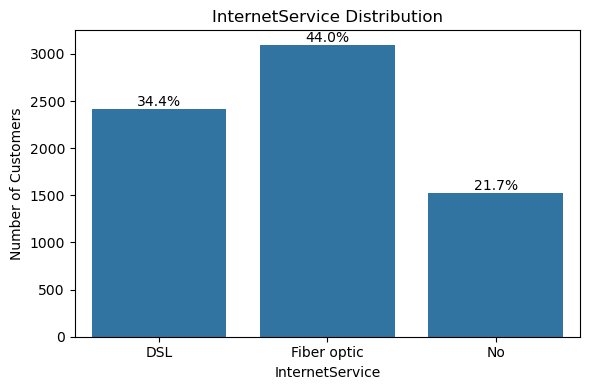

In [25]:
plot_class_distribution(df, "Contract")
plot_class_distribution(df, "PaymentMethod")
plot_class_distribution(df, "InternetService")

### insight
"The gender distribution is relatively balanced and does not indicate class imbalance. However, the target variable is moderately imbalanced, with approximately 73% of customers retained and 27% having churned. Since the minority class represents the business outcome of interest, model evaluation will prioritize metrics such as precision, recall, F1-score, and ROC-AUC rather than accuracy alone. This ensures the model effectively identifies customers at risk of churning while minimizing missed retention opportunities.

## Categorical Value Verification

Categorical variables should contain consistent and valid values. This step verifies the unique categories in each categorical feature to detect spelling inconsistencies, unexpected labels, or formatting issues.

In [26]:
# Inspect unique values in categorical columns to identify inconsistent labels, spelling differences, or unexpected categories.

# selects all columns with the object datatype (typically categorical or text columns).
# ".columns" returns column names.

def categorical_value_report(df):
    """
    Return unique values for all categorical columns.
    """
    categorical_columns = df.select_dtypes(
        include=["object", "category"]
    ).columns

    return {
        column: df[column].dropna().unique().tolist()
        for column in categorical_columns
    }

for column, values in categorical_value_report(df).items():
    print(f"{column}: {values}")

customerID: ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU', '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU', '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS', '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB', '8779-QRDMV', '1680-VDCWW', '1066-JKSGK', '3638-WEABW', '6322-HRPFA', '6865-JZNKO', '6467-CHFZW', '8665-UTDHZ', '5248-YGIJN', '8773-HHUOZ', '3841-NFECX', '4929-XIHVW', '6827-IEAUQ', '7310-EGVHZ', '3413-BMNZE', '6234-RAAPL', '6047-YHPVI', '6572-ADKRS', '5380-WJKOV', '8168-UQWWF', '8865-TNMNX', '9489-DEDVP', '9867-JCZSP', '4671-VJLCL', '4080-IIARD', '3714-NTNFO', '5948-UJZLF', '7760-OYPDY', '7639-LIAYI', '2954-PIBKO', '8012-SOUDQ', '9420-LOJKX', '6575-SUVOI', '7495-OOKFY', '4667-QONEA', '1658-BYGOY', '8769-KKTPH', '5067-XJQFU', '3957-SQXML', '5954-BDFSG', '0434-CSFON', '1215-FIGMP', '0526-SXDJP', '0557-ASKVU', '5698-BQJOH', '5122-CYFXA', '8627-ZYGSZ', '3410-YOQBQ', '3170-NMYVV', '7410-OIEDU', '2273-Q

In [27]:
# check the number of unique values in each column
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

### Filling the "total_charges" column with median value for customers with zero tenure is not ideal for these specific rows because a brand-new customer shouldn't suddenly have a large lifetime charge.

A more business-appropriate approach is to leave the Totalcharges as zero

In [28]:
# Customers with tenure = 0 are newly acquired customers with no billing history.
# Instead of imputing missing TotalCharges values with a statistical measure,
# we assign 0 because their cumulative charges should logically be zero.
df.loc[df["tenure"] == 0, "TotalCharges"] = 0

In [29]:
# Verify results
df[df["tenure"] == 0][["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,0.0
753,0,20.25,0.0
936,0,80.85,0.0
1082,0,25.75,0.0
1340,0,56.05,0.0
3331,0,19.85,0.0
3826,0,25.35,0.0
4380,0,20.00,0.0
5218,0,19.70,0.0
6670,0,73.35,0.0


### Insight
Missing values in **TotalCharges** column were investigated and found only among customers with zero tenure. Since these represent newly acquired customers with no billing history, replacing them with statistical values such as the median would introduce unrealistic lifetime charges. Therefore, TotalCharges was set to zero based on the business logic that customers with zero tenure have generated no cumulative charges."

## Data Quality Summary

After completing the cleaning process, a final review is performed to confirm that the dataset is free from major quality issues. This ensures the data is suitable for exploratory data analysis and predictive modeling.

In [30]:
def validate_cleaned_data(df):
    """
    Generate a final data-quality report.
    """
    return {
        "shape": df.shape,
        "missing_values": df.isna().sum(),
        "duplicate_rows": df.duplicated().sum(),
        "data_types": df.dtypes
    }


validation_report = validate_cleaned_data(df)

print("Final Dataset Shape:", validation_report["shape"])

print("\nMissing Values:")
display(validation_report["missing_values"])

print("\nDuplicate Rows:")
print(validation_report["duplicate_rows"])

print("\nData Types:")
display(validation_report["data_types"])

Final Dataset Shape: (7043, 21)

Missing Values:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Duplicate Rows:
0

Data Types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [31]:
def assert_clean_data(df):
    """
    Validate that the cleaned dataset meets minimum quality requirements.
    """
    assert df.isna().sum().sum() == 0, \
        "Dataset still contains missing values."

    assert df.duplicated().sum() == 0, \
        "Dataset still contains duplicate rows."

    assert df["TotalCharges"].dtype.kind in "fi", \
        "TotalCharges is not numeric."

    return True


assert_clean_data(df)

True

## Save Cleaned Dataset

The cleaned dataset is saved for use in subsequent stages of the project, including exploratory data analysis, feature engineering, and model development. Keeping a separate cleaned dataset preserves the integrity of the original raw data.

In [32]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [33]:
def save_dataframe(df, filepath):
    """
    Save a DataFrame to CSV, creating parent directories if necessary.
    """
    filepath = Path(filepath)

    filepath.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    df.to_csv(filepath, index=False)

    print(f"Saved dataset to: {filepath}")

save_dataframe(
    df,
    "../data/cleaned/churn_clean.csv"
)

Saved dataset to: ..\data\cleaned\churn_clean.csv


# The BIG function: clean_telco_data()

combine the actual cleaning operations into one reusable pipeline function.

def clean_telco_data(df):
    """
    Apply the complete Telco customer churn cleaning workflow.
    """
    df = df.copy()

    # Convert TotalCharges to numeric
    df = convert_to_numeric(df, "TotalCharges")

    # Apply business rule for zero-tenure customers
    df = fix_zero_tenure_total_charges(df)

    # Remove duplicate rows
    df = remove_duplicates(df)

    return df

# Then your actual cleaning notebook becomes:

df = load_data("../data/raw/Telco_Customer_Churn.csv")

df = clean_telco_data(df)

assert_clean_data(df)

save_dataframe(df, "../data/cleaned/churn_clean.csv")